# <center>Medical Cost Prediction</center>

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#### 1. Data importing  and Basics

In [5]:
dt=pd.read_csv("health_insurance.csv")

In [6]:
dt.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
dt.shape

(1338, 7)

In [9]:
dt.describe(include=["object","int","float"])

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [10]:
## finding and treating missing values 

In [11]:
dt.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
# Duplicated values 

In [13]:
dt.duplicated().sum()

np.int64(1)

In [14]:
# removing duplicated

In [15]:
dt=dt.drop_duplicates()

In [16]:
dt.duplicated().sum()

np.int64(0)

#### 2.Data Visualization

In [17]:
#####Univariate Analysis

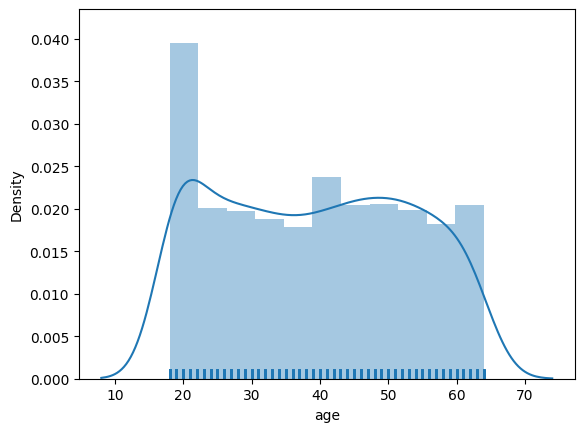

In [18]:
sns.distplot(dt["age"],kde=True,rug=True)
plt.show()

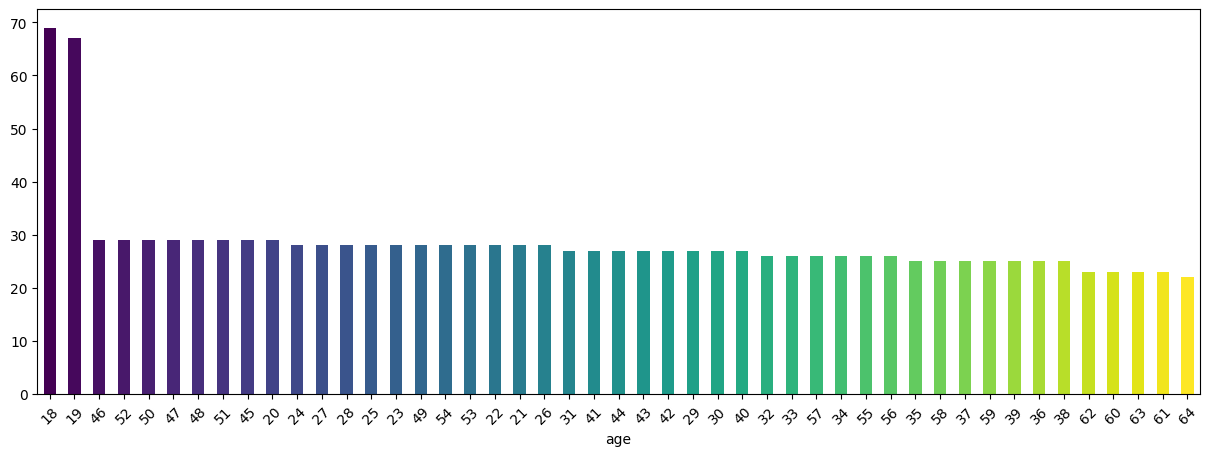

In [19]:
plt.figure(figsize=(15,5))
dt["age"].value_counts().plot(kind='bar',color=plt.cm.viridis(np.linspace(0, 1, len(dt["age"].value_counts()))))
plt.xticks(rotation=45)
plt.show()


In [20]:
# GENDER 

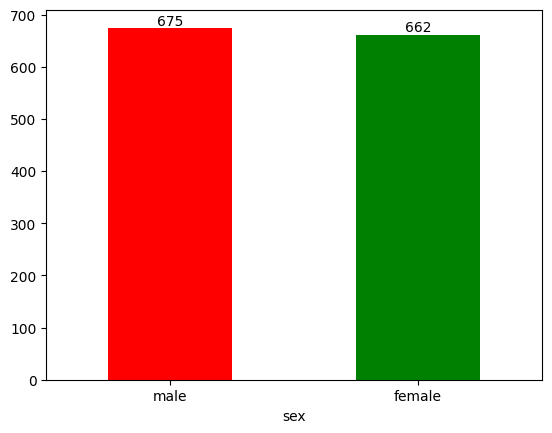

In [21]:
ax=dt["sex"].value_counts().plot(kind='bar',color=["Red","Green"])
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

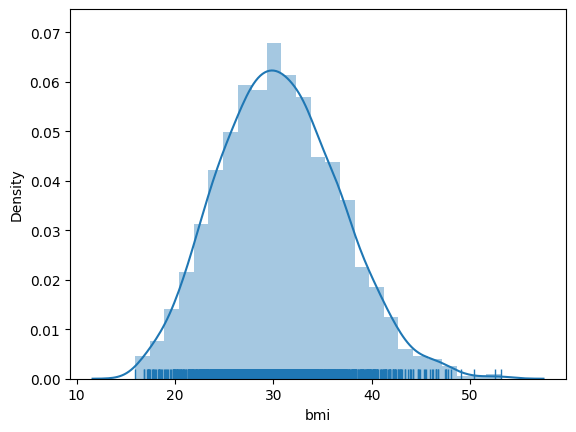

In [22]:
# bmi 
sns.distplot(dt["bmi"],kde=True,rug=True)
plt.show()

In [23]:
#children

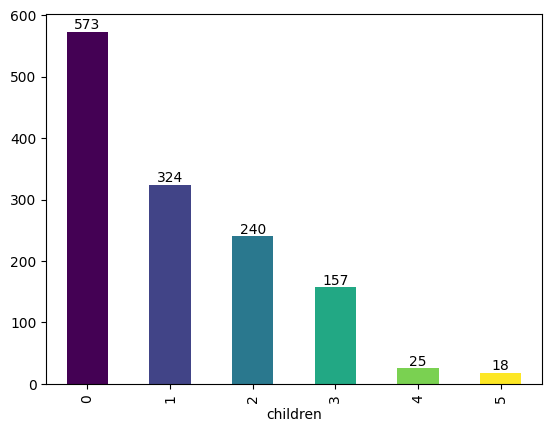

In [24]:
ax=dt["children"].value_counts().plot(kind='bar',color=plt.cm.viridis(np.linspace(0,1,len(dt["children"].value_counts()))))

for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [25]:
# smoker

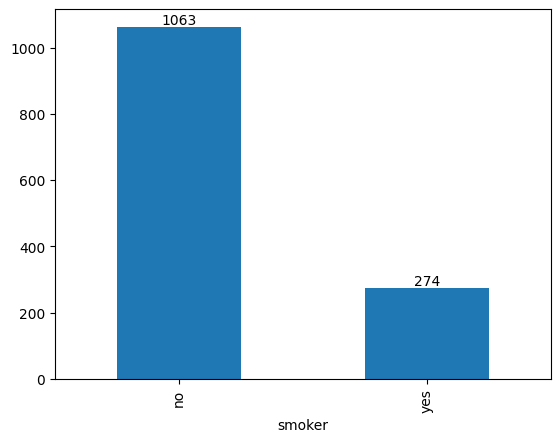

In [26]:
# smoker
ax=dt["smoker"].value_counts().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [27]:
#charges

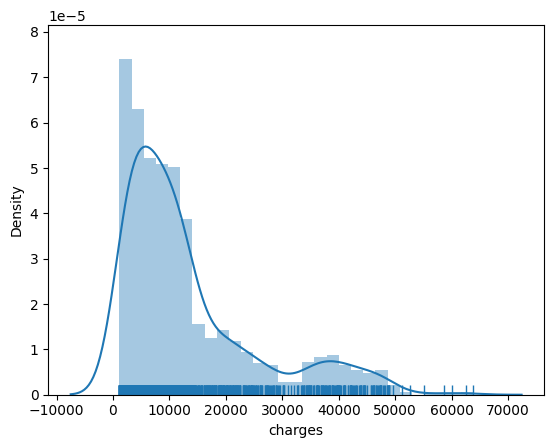

In [28]:
sns.distplot(dt["charges"],kde=True,rug=True)
plt.show()


In [29]:
#region

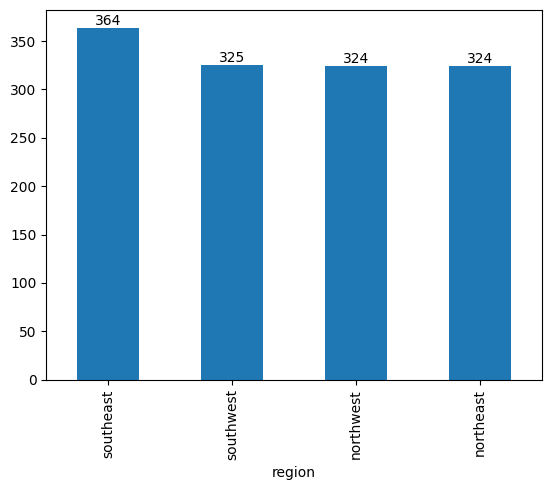

In [30]:
ax=dt["region"].value_counts().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

#### BI-Variate Analysis

In [31]:
dt.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [32]:
# scatter plot between age and charges

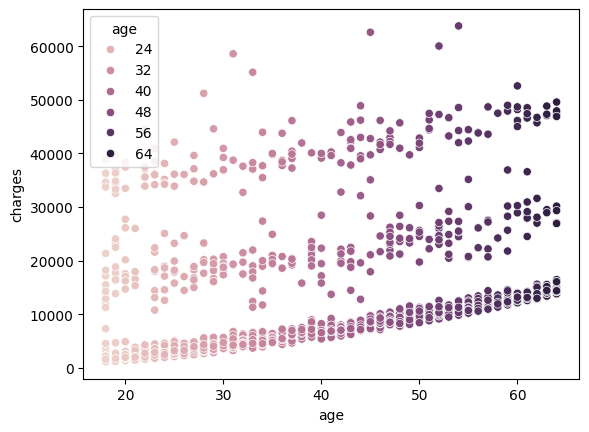

In [33]:
sns.scatterplot(x=dt["age"],y=dt["charges"],hue=dt["age"])
plt.show()

In [34]:
dt.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

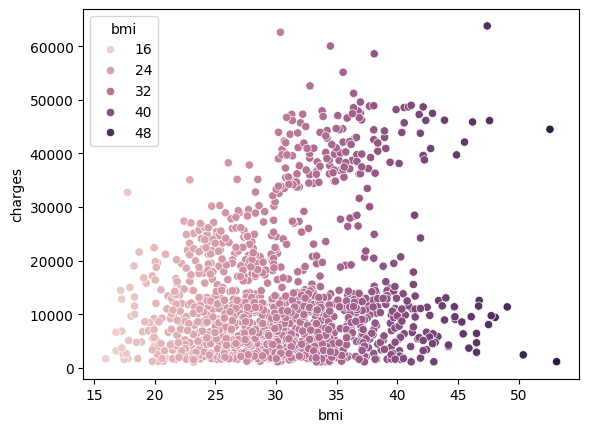

In [35]:
# bmi vs charges
sns.scatterplot(x=dt["bmi"],y=dt["charges"],hue=dt["bmi"])
plt.show()

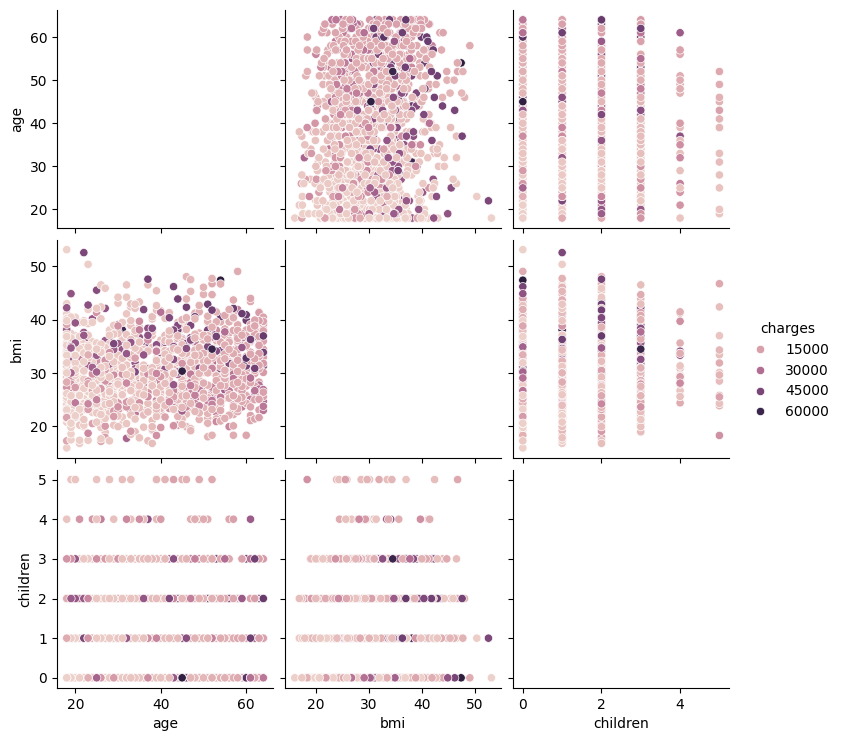

In [36]:
#pair plot

sns.pairplot(dt,hue="charges",diag_kind="kde")
plt.show()


In [37]:
 # Co relation Matrix 

corr=dt.select_dtypes(include=np.number).corr()

sns.heatmap(corr,annot=True)
plt.show()

#### 3.OUTLIER

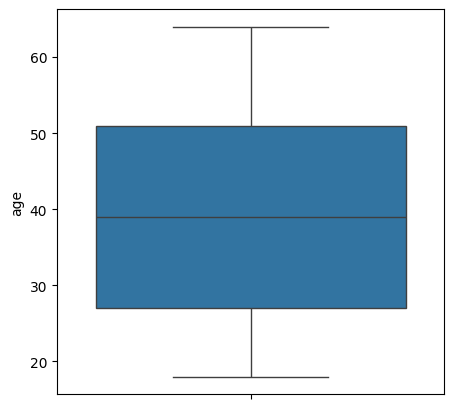

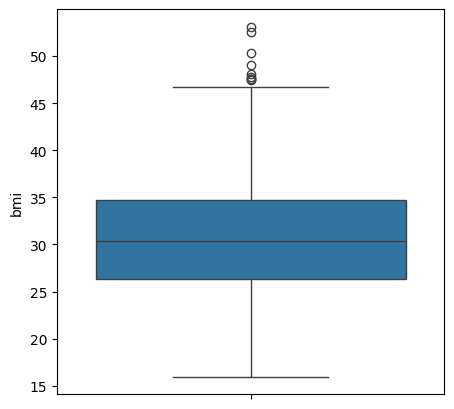

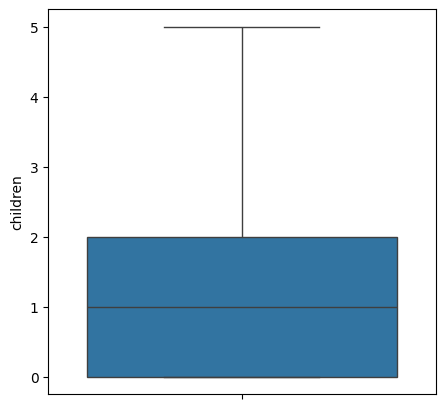

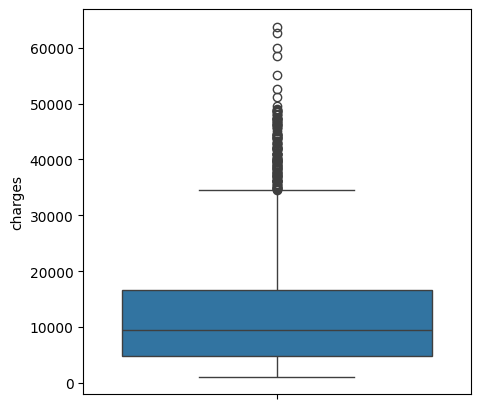

In [38]:
for col in dt.select_dtypes(include='number').columns:
    plt.figure(figsize=(5,5))
    sns.boxplot(dt[col])
    plt.show()

In [39]:
## calculate the percentage of outlier 
for col in dt.select_dtypes(include='number').columns:

  Q1=dt[col].quantile(0.25)
  Q3=dt[col].quantile(0.75)

  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  outlier=dt[(dt[col]<lower)|(dt[col]>upper)]

  percentage=(len(outlier)/len(dt))*100

  print(col, ":", round(percentage,2), "%")



age : 0.0 %
bmi : 0.67 %
children : 0.0 %
charges : 10.4 %


In [40]:
#checking skewness 

In [41]:
for col in dt.select_dtypes(include="number").columns:
    print(col,":",dt[col].skew())

age : 0.054780773126998195
bmi : 0.28391419385321137
children : 0.9374206440474123
charges : 1.5153909108403483


In [42]:
# charges the Target Variable is bit skewed we aill use Log Transformation to remove skewness

In [43]:
dt["charges_log"]=np.log1p(dt["charges"])
print("Skewness afte log",dt["charges_log"].skew())

Skewness afte log -0.08955835073325419


##### dt_log =dt.copy() storing data frame into new variable

In [44]:
#### dt_log= dt ( after  applying log to charges column)
dt_log=dt.copy()


In [45]:
dt_log=dt_log.drop("charges",axis=1)

In [46]:
dt_log.shape

(1337, 7)

In [47]:
 ## the charges colum is removes dt_log=dt_log.drop("charges",axis=1)


In [48]:
dt_log.shape

(1337, 7)

In [49]:
dt_log.head()

,age,sex,bmi,children,smoker,region,charges_log
0,19,female,27.900,0,yes,southwest,9.734236
1,18,male,33.770,1,no,southeast,7.453882
2,28,male,33.000,3,no,southeast,8.400763
3,33,male,22.705,0,no,northwest,9.998137
4,32,male,28.880,0,no,northwest,8.260455


#### 5.Encoding Categorical Variable 

In [50]:
 #GET UNDER DUMMIES 

In [51]:
dt_encoding=dt_log.copy()

In [52]:
dt_encoding = pd.get_dummies(dt_encoding,columns=dt_encoding.select_dtypes(include='object').columns,drop_first=True).astype(int)

In [53]:
dt_encoding.columns


Index(['age', 'bmi', 'children', 'charges_log', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

##### SPLIT THE DATA SET INTO X AND Y 

In [54]:
X=dt_encoding.drop("charges_log",axis=1)
y=dt_encoding["charges_log"]


In [55]:
y.head()

0    9
1    7
2    8
3    9
4    8
Name: charges_log, dtype: int64

##### Feature engineering using VIF

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [57]:
X_vif=pd.DataFrame()
X_vif["feature"]=X.columns
X_vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

In [58]:
print(X_vif)

            feature        VIF
0               age   7.645057
1               bmi  11.232386
2          children   1.809663
3          sex_male   2.000808
4        smoker_yes   1.260889
5  region_northwest   1.884156
6  region_southeast   2.266495
7  region_southwest   1.959759


In [59]:
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0


##### train test split

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

#### Apply Standard Scaling

In [61]:
from sklearn.preprocessing import StandardScaler

# define numeric columns
num_col = ["age", "bmi", "children"]

# initialize scaler
scaler = StandardScaler()

# make copies of train and test
X_scaled_train = X_train.copy()
X_scaled_test = X_test.copy()

# fit ONLY on train, transform both
X_scaled_train[num_col] = scaler.fit_transform(X_train[num_col])
X_scaled_test[num_col] = scaler.transform(X_test[num_col]) 

#### MODEL

#### 1. Linear Regression

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train model
LR = LinearRegression()
LR.fit(X_scaled_train, y_train)

# Predict (log scale) Predict Train and test 
y_pred_log = LR.predict(X_scaled_test) #test
y_pred_train_log=LR.predict(X_scaled_train)#train

# Convert test back to original scale 
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

#convert train to actual scale

y_pred_train=np.expm1(y_pred_train_log)
y_train_actual =np.expm1(y_train)

# Evaluation _test
test_mse = mean_squared_error(y_test_actual, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_pred)
#evaluation_train

train_mse=mean_squared_error(y_train_actual, y_pred_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual, y_pred_train)

#print Test
print("Test_MSE", test_mse)
print("Test_RMSE", test_rmse)
print("Test_R2", test_r2)

print("_"*50)

#Print Train

print("Train_MSE", train_mse)
print("Train_RMSE", train_rmse)
print("Train_R2", train_r2)

print("_"*50)

#check for over fit 
overfit = "Yes" if (train_r2 - test_r2) > 0.05 else "No"

print("Over Fitting",overfit)

Test_MSE 30538446.669933062
Test_RMSE 5526.160210302725
Test_R2 0.5340094555126594
__________________________________________________
Train_MSE 32785025.543816693
Train_RMSE 5725.820949332654
Train_R2 0.35918552292777617
__________________________________________________
Over Fitting No


#### 2.Decision Tree Regressor

In [63]:
 from sklearn.tree import DecisionTreeRegressor

In [64]:
DT=DecisionTreeRegressor()
# Model Fitting
DT.fit(X_train,y_train)

# predict log scale Test and Train
y_pred_log=DT.predict(X_test) # test predict
y_pred_train_predict=DT.predict(X_train) #Train Predict

# actual conversion to scale  Test
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

#TrainConversion to actual scale
y_pred_train=np.expm1(y_pred_train_predict)
y_train_actual=np.expm1(y_train)

#evaluation TEST
test_mse=mean_squared_error(y_test_actual,y_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_actual,y_pred)

#Evaluation Train
train_mse=mean_squared_error(y_train_actual,y_pred_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual,y_pred_train)

# Result Test
print("test_mse",test_mse)
print("test_rmse",test_rmse)
print("test_r2",test_r2)

print("_"*70)

#resut_train
print("train_mse",train_mse)
print("train_rmse",train_rmse)
print("train_r2",train_r2)

print("_"*70)

overfit1="Yes" if (train_r2-test_r2)>0.05 else "No"
print("Overfitting",overfit1)


test_mse 36374659.032775134
test_rmse 6031.140773748788
test_r2 0.44495385271469023
______________________________________________________________________
train_mse 102539.5797305551
train_rmse 320.2180190597573
train_r2 0.9979957664795344
______________________________________________________________________
Overfitting Yes


#### 3. Random Forest

In [65]:
from sklearn.ensemble import RandomForestRegressor


In [68]:
RD=RandomForestRegressor(n_estimators=100,random_state=42)
RD.fit(X_train,y_train)

#predict log scale
Y_pred_log=RD.predict(X_test) #test pred
y_pred_train_log=RD.predict(X_train) #train pred

#actual scale test
y_pred=np.expm1(Y_pred_log)
y_test_actual=np.expm1(y_test)

#actual scale train
y_pred_train=np.expm1(y_pred_train_log)
y_tran_actual=np.expm1(y_train)

#evaluation

#test_evaluation
test_mse=mean_squared_error(y_test_actual,y_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_actual,y_pred)

#train_evaluation
train_mse=mean_squared_error(y_train_actual,y_pred_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual,y_pred_train)

#evaluation result
print("Test Result")
print("Test_mse",test_mse)
print("test_rmse",test_rmse)
print("test_r2",test_r2)

print("_")

print("Train Result")
print("train_mse",train_mse)
print("train_rmse",train_rmse)
print("train_r2",train_r2)

print("_-"*50)

overfit3="Yes" if (train_r2-test_r2)>0.05 else "No"
print("Overfitting",overfit3)
                  



Test Result
Test_mse 21233945.276218466
test_rmse 4608.030520321938
test_r2 0.6759881788414117
_
Train Result
train_mse 3993526.159259866
train_rmse 1998.3808844311602
train_r2 0.9219427365093815
_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-
Overfitting Yes


#### 4. Support Vector Regressor(SVR)

In [69]:
###4. Suppoer Vector Regressor(SVR)
from sklearn.svm import SVR

svr=SVR()
svr.fit(X_scaled_train, y_train)

# predict log scale
y_pred_log=svr.predict(X_scaled_test) #test pred
y_pred_train_log=svr.predict(X_scaled_train)#train pred

 
# Test reverse log scale actual pred 
y_pred=np.expm1(y_pred_log)
y_test_actual=np.expm1(y_test)

#Train reverse log scale actual pred 
y_pred_train=np.expm1(y_pred_train_log)
y_train_actual =np.expm1(y_train)

#Evaluation
#test Evalualtion

test_mse=mean_squared_error(y_test_actual,y_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_actual,y_pred)

#Train Evaluation
train_mse=mean_squared_error(y_train_actual,y_pred_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual,y_pred_train)

#result
print("test Result")
print("test_mse",test_mse)
print("test_rmse",test_rmse)
print("test_r2",test_r2)

print("_")

print("train Result")
print("train_mse",train_mse)
print("train_rmse",train_rmse)
print("train_r2",train_r2)

print("-_"*60)

overfit4="Yes" if (train_r2-test_r2)>0.05 else "No"
print("Overfitting",overfit4)


test Result
test_mse 23207959.496091124
test_rmse 4817.464010876586
test_r2 0.6458664122995044
_
train Result
train_mse 15374179.336209591
train_rmse 3920.9921367186635
train_r2 0.6994970561001792
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Overfitting Yes


##### 5. KNN REGRESSOR

In [70]:
from sklearn.neighbors import KNeighborsRegressor

In [71]:
KNN=KNeighborsRegressor(n_neighbors=3)
KNN.fit(X_scaled_train, y_train)

#predict on log 
y_pred_log=KNN.predict(X_scaled_test)

# actual_value_y
y_pred=np.expm1(y_pred_log)
y_test_actual=np.expm1(y_test)

#Evaluation

mse=mean_squared_error(y_test_actual,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test_actual,y_pred)

#result
print(mse)
print(rmse)
print(r2)

32726723.61007475
5720.727542024244
0.500618223344008


##### 6.XGBOOST

In [72]:
from xgboost import XGBRegressor

xgb=XGBRegressor()
xgb.fit(X_train,y_train)

#predict log scale
Y_pred_log=xgb.predict(X_test) #Test
y_pred_train_log=xgb.predict(X_train) #Train

#actual scale Test
y_pred=np.expm1(Y_pred_log)
y_test_actual=np.expm1(y_test)

#actual Scale Train
y_pred_train=np.expm1(y_pred_train_log)
y_train_actual=np.expm1(y_train)

#evaluation
#Test
test_mse=mean_squared_error(y_test_actual,y_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_actual,y_pred)

#Train
train_mse=mean_squared_error(y_train_actual,y_pred_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual,y_pred_train)

#evaluation result
print("test Result")
print("test_mse",test_mse)
print("test_rmse",test_rmse)
print("test_r2",test_r2)

print("_")

print("train Result")
print("train_mse",train_mse)
print("train_rmse",train_rmse)
print("train_r2",train_r2)

print("-_"*60)

overfit5="Yes" if (train_r2-test_r2)>0.05 else "No"
print("Overfitting",overfit5)


test Result
test_mse 33667408.14166717
test_rmse 5802.362289763297
test_r2 0.4862641829500951
_
train Result
train_mse 925837.5189869158
train_rmse 962.2045099597673
train_r2 0.9819036259468359
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Overfitting Yes


##### 7.L1 Regressor

In [73]:
from sklearn.linear_model import Lasso

l1=Lasso(alpha=0.05)
l1.fit(X_scaled_train,y_train)

#predict

y_log_predict=l1.predict(X_scaled_test)

# log reverse to actual

y_pred=np.expm1(y_log_predict)
y_test_actual=np.expm1(y_test)

#eveluation

mse=mean_squared_error(y_test_actual,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test_actual,y_pred)

#result
print(mse)
print(rmse)
print(r2)

31172033.269787733
5583.192032322347
0.524341466572775


##### 8.LGBM REGRESSOR

In [78]:
from lightgbm import LGBMRegressor
lgbm=LGBMRegressor()

lgbm.fit(X_scaled_train,y_train)

#predict
y_log_pred=lgbm.predict(X_scaled_test)#test predict
y_train_pred=lgbm.predict(X_scaled_train)#Train Predict

#reverse log Test
y_pred=np.expm1(y_log_pred)
y_test_actual=np.expm1(y_test)

#reverse log train
y_pred_train=np.expm1(y_train_pred)
y_train_actual=np.expm1(y_train)

#evaluation
#test
test_mse=mean_squared_error(y_test_actual,y_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_actual,y_pred)

#train

train_mse=mean_squared_error(y_train_actual,y_pred_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual,y_pred_train)


#result
print("Test Result")

print("test_mse",test_mse)
print("test_rmse",test_rmse)
print("test_r2",test_r2)

print("Train result")

print("train_mse",train_mse)
print("train_rmse",train_rmse)
print("train_r2",train_r2)

overfit6="Yes" if (train_r2-test_r2)>0.05 else "No"
print("Overfitting",overfit6)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 98
[LightGBM] [Info] Number of data points in the train set: 1002, number of used features: 8
[LightGBM] [Info] Start training from score 8.600798
Test Result
test_mse 20740864.05871888
test_rmse 4554.213879334048
test_r2 0.6835121759687881
Train result
train_mse 7865815.9283698285
train_rmse 2804.606198447445
train_r2 0.8462551534648619
Overfitting Yes


##### 9.Stacking

In [79]:
from sklearn.ensemble import StackingRegressor

# model used (RF, XGB, LGBM)

# MODEL DEFINING
rf1=RandomForestRegressor()
xgb=XGBRegressor()
lgbm=LGBMRegressor(verbose=-1)


#COBNINING ALL THREE MODEL

estimators=[("rf",rf1),("xgb",xgb),("lgbm",lgbm)]

# Stacking MODEL

stack_model= StackingRegressor(estimators=estimators,final_estimator=LinearRegression())

#model fitting

stack_model.fit(X_train,y_train)

#model predict log train and test

y_pred_log=stack_model.predict(X_test) #test
y_pred_log_train=stack_model.predict(X_train)# X_train

# actual conversion log reverse
#test
y_pred=np.expm1(y_pred_log)
y_test_actual=np.expm1(y_test)

#Train
y_pred_train=np.expm1(y_pred_log_train)
y_train_actual=np.expm1(y_train)

#evaluation
#Test
test_mse=mean_squared_error(y_test_actual,y_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_actual,y_pred)

#Train
train_mse=mean_squared_error(y_train_actual,y_pred_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual,y_pred_train)

#evaluation result
print("test Result")
print("test_mse",test_mse)
print("test_rmse",test_rmse)
print("test_r2",test_r2)

print("_")

print("train Result")
print("train_mse",train_mse)
print("train_rmse",train_rmse)
print("train_r2",train_r2)

print("-_"*60)

overfit5="Yes" if (train_r2-test_r2)>0.05 else "No"
print("Overfitting",overfit5)



test Result
test_mse 20844642.74241215
test_rmse 4565.593361482399
test_r2 0.6819286021268344
_
train Result
train_mse 7377173.304999245
train_rmse 2716.0952312095474
train_r2 0.85580613785412
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Overfitting Yes


#### HYPER PARAMETER TUNING 

##### 1.Random Forest (Grid search CV) 

In [80]:
from sklearn.model_selection import GridSearchCV

In [81]:
param_grid={ "n_estimators":[100,200,300],"max_depth":[None,5,10,15],"min_samples_split":[2,5,10], "min_samples_leaf":[1,2,4]}

rf2=RandomForestRegressor()

grid=GridSearchCV(estimator=rf2,param_grid=param_grid, scoring="neg_mean_squared_error",n_jobs=-1)

grid.fit(X_train,y_train)

#best params
print("Best_Params",grid.best_params_)

Best_Params {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [82]:
## model fitting  with best parameter
best_rf = grid.best_estimator_

#log predict
y_log_pred=best_rf.predict(X_test)
y_log_train_pred=best_rf.predict(X_train)

#reverse log test

y_pred=np.expm1(y_log_pred)
y_test_actual=np.expm1(y_test)

#log reverse Train
y_pred_train_actual=np.expm1(y_log_train_pred)
y_train_actual=np.expm1(y_train)

#Evaluation
# test
test_mse=mean_squared_error(y_test_actual,y_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_actual,y_pred)

#Train
train_mse=mean_squared_error(y_train_actual,y_pred_train_actual)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train_actual,y_pred_train_actual)

#result
print("Test Result")
print("test_mse",test_mse)
print("test_rmse",test_rmse)
print("test_r2",test_r2)
print("_"*100)

#train result

print("Train Result")
print("train_mse",train_mse)
print("train_rmse",train_rmse)
print("train_r2",train_r2)
print("_"*100)




Test Result
test_mse 20204550.154875576
test_rmse 4494.947180432221
test_r2 0.6916958668673213
____________________________________________________________________________________________________
Train Result
train_mse 11495242.779201306
train_rmse 3390.463505068489
train_r2 0.7753145569300481
____________________________________________________________________________________________________


In [83]:
from sklearn.model_selection import cross_val_score

# Cross-validation on TRAIN data
cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV R2 Scores: [0.7150287  0.81980181 0.7685407  0.85022034 0.79882006]
Mean CV R2: 0.7904823242742692


#### RESULT TABLE

In [85]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def get_metrics(model, Xtr, Xte):
    
    train_pred = np.expm1(model.predict(Xtr))
    test_pred = np.expm1(model.predict(Xte))
    
    y_tr = np.expm1(y_train)
    y_te = np.expm1(y_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_te, test_pred))
    
    train_r2 = r2_score(y_tr, train_pred)
    test_r2 = r2_score(y_te, test_pred)
    
    overfit = "Yes" if (train_r2 - test_r2) > 0.05 else "No"
    
    return [train_rmse, test_rmse, train_r2, test_r2, overfit]


data = [
    ["Linear Regression"] + get_metrics(LR, X_scaled_train, X_scaled_test),
    ["Decision Tree"] + get_metrics(DT, X_train, X_test),
    ["Random Forest"] + get_metrics(best_rf, X_train, X_test),
    ["SVR"] + get_metrics(svr, X_scaled_train, X_scaled_test),
    ["Stacking"] + get_metrics(stack_model, X_train, X_test),
     ["best_rf"] + get_metrics(best_rf, X_train, X_test)
    
]

df = pd.DataFrame(data, columns=[
    "Model", "Train RMSE", "Test RMSE", "Train R2", "Test R2", "Overfitting"
])

# sort best model
df = df.sort_values(by="Test R2", ascending=False)

print(df)

               Model   Train RMSE    Test RMSE  Train R2   Test R2 Overfitting
5            best_rf  3390.463505  4494.947180  0.775315  0.691696         Yes
2      Random Forest  3390.463505  4494.947180  0.775315  0.691696         Yes
4           Stacking  2716.095231  4565.593361  0.855806  0.681929         Yes
3                SVR  3920.992137  4817.464011  0.699497  0.645866         Yes
0  Linear Regression  5725.820949  5526.160210  0.359186  0.534009          No
1      Decision Tree   320.218019  6031.140774  0.997996  0.444954         Yes


SyntaxError: invalid syntax (2049194424.py, line 1)

In [86]:
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(best_rf, "best_rf_model.pkl")   

['best_rf_model.pkl']